#Velocity analysis

Folder on Desktop named 'velocity_suppression_analysis' with file named `all_mice_long.csv` with columns:

`mouse`, `mouse_id`, `session`, `cohort`, `epoch`, `mean_velocity`

- `SESSION_MEAN_THRESHOLD`: exclude sessions with very low overall movement.
- `OUTPUT_DIR`: where figures and CSVs are saved.

In [114]:
#Import packages
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

In [138]:
#Configure your things
DATA_PATH = Path("/Users/suthardr/Desktop/mega_sheet/mega_sheet_allmice.csv")
OUTPUT_DIR = Path("/Users/suthardr/Desktop/mega_sheet/behavior_velocity_outputs")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

#Threshold for excluding mice - mean vel for session has to be greater than this
SESSION_MEAN_THRESHOLD = 5.0  # cm/s

# Plot style
TRACE_COLOR = "#7EA6E0"
ITI_COLOR = "#E0A070"
TRACE_EDGE = "#5B89D0"
ITI_EDGE = "#D68B56"

COHORT_STYLES = {
    "cohort1": dict(color="#5AA382", marker="o"), #2p FriendsCohort
    "cohort2": dict(color="#7F7BBE", marker="^"), #Behavior Cohort, Hadas Mice
    "cohort3": dict(color="#D07A3E", marker="s"), #Amithi
}

In [139]:
# Load data, checks the columns are in the csv and prints
df = pd.read_csv(DATA_PATH)

required_cols = {"mouse", "mouse_id", "session", "cohort", "epoch", "mean_velocity"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["mean_velocity"] = pd.to_numeric(df["mean_velocity"], errors="coerce")

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
display(df.head())

print("\nSessions:", sorted(df["session"].dropna().unique()))
print("Epochs:", sorted(df["epoch"].dropna().unique()))
print("Mice:", df["mouse_id"].nunique())

Loaded: /Users/suthardr/Desktop/mega_sheet/mega_sheet_allmice.csv
Shape: (220, 6)


,mouse,epoch,mean_velocity,mouse_id,session,cohort
0,rotary_20260714_672B,Tone,13.717077,672B,TFC,cohort1
1,rotary_20260714_672B,Trace,42.226362,672B,TFC,cohort1
2,rotary_20260714_672B,Shock,59.367426,672B,TFC,cohort1
3,rotary_20260714_672B,ITI,20.535201,672B,TFC,cohort1
4,rotary_20260714_671B,Tone,32.173001,671B,TFC,cohort1



Sessions: ['RecallA', 'RecallB', 'TFC']
Epochs: ['ITI', 'Shock', 'Tone', 'Trace']
Mice: 20


In [143]:
#Build analysis tables
# 1. Exclude low-movement sessions
session_mean = (
    df.groupby(["session", "mouse_id"], as_index=False)["mean_velocity"]
      .mean()
      .rename(columns={"mean_velocity": "session_mean_velocity"})
)

valid_sessions = session_mean[session_mean["session_mean_velocity"] > SESSION_MEAN_THRESHOLD].copy()
df_filt = df.merge(
    valid_sessions[["session", "mouse_id", "session_mean_velocity"]],
    on=["session", "mouse_id"],
    how="inner"
)
# 2. Reshape your data
# Per-mouse/session/epoch wide
epoch_tbl = (
    df_filt.pivot_table(
        index=["session", "mouse_id", "cohort"], columns="epoch",
        values="mean_velocity", aggfunc="mean",
    ).reset_index()
)
for col in ["ITI", "Tone", "Trace", "Shock"]:
    if col not in epoch_tbl.columns:
        epoch_tbl[col] = np.nan

# 3. Table with Recall-only and Tone+Trace average
recall_tbl = epoch_tbl[epoch_tbl["session"].isin(["RecallA", "RecallB"])].copy()
recall_tbl["ToneTrace"] = recall_tbl[["Tone", "Trace"]].mean(axis=1)

# 4. Matched mice in Recall A and B
matched_mice = (
    recall_tbl.pivot(index="mouse_id", columns="session", values="ITI")
    .dropna()
    .index.tolist()
)
recall_tbl_matched = recall_tbl[recall_tbl["mouse_id"].isin(matched_mice)].copy()

# 5. Save tables
session_mean.to_csv(OUTPUT_DIR / "session_mean_velocity_all_sessions.csv", index=False)
epoch_tbl.to_csv(OUTPUT_DIR / "epoch_velocity_summary_gt5cmps.csv", index=False)
recall_tbl.to_csv(OUTPUT_DIR / "recall_metrics_allmice_gt5cmps.csv", index=False)
recall_tbl_matched.to_csv(OUTPUT_DIR / "recall_metrics_matched_gt5cmps.csv", index=False)

print("Mice included per session (after threshold):")
display(valid_sessions.groupby("session")["mouse_id"].nunique().rename("n_included").to_frame())
print("Matched RecallA/RecallB mice:", matched_mice)

Mice included per session (after threshold):


,n_included
session,
RecallA,18
RecallB,12
TFC,20


Matched RecallA/RecallB mice: ['671B', '671L', '671N', '672B', '672L', '672N', '672R', '759', 'chandler', 'monica', 'rachel']


In [144]:
#Plotting functions
plt.rcParams.update({
    "font.family": "Arial",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

#Save figure formatting
def save_fig(fig, name):
    png = OUTPUT_DIR / f"{name}.png"
    pdf = OUTPUT_DIR / f"{name}.pdf"
    fig.savefig(png, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())
    fig.savefig(pdf, bbox_inches="tight", facecolor=fig.get_facecolor())
    print("Saved:", png)
    print("Saved:", pdf)

#Axes style
def style_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.3)
    ax.spines["bottom"].set_linewidth(1.3)
    ax.tick_params(width=1.1, length=4)

#Computes and draws SEM on plot
def mean_sem(values):
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return float(np.mean(values)), np.nan
    return float(np.mean(values)), float(np.std(values, ddof=1) / np.sqrt(len(values)))

def add_mean_sem(ax, x, values, color="black"):
    m, s = mean_sem(values)
    ax.errorbar([x], [m], yerr=[s], fmt="o", color=color, markersize=5,
                elinewidth=1.5, capsize=4, capthick=1.2, zorder=5)
    return m, s

#Draws a epoch vs ITI plot with paired t-tests
def paired_box_panel(ax, d, target_col, target_label, p_label=True):
    y1 = d[target_col].astype(float).values
    y2 = d["ITI"].astype(float).values
    n = len(d)
    t_p = ttest_rel(y1, y2).pvalue if n > 1 else np.nan

    box = ax.boxplot(
        [y1, y2], positions=[1, 2], widths=0.42, patch_artist=True,
        showfliers=False,
        medianprops=dict(linewidth=2.6), whiskerprops=dict(linewidth=2.2),
        capprops=dict(linewidth=2.2), boxprops=dict(linewidth=2.0),
    )
    for i, (fill, edge) in enumerate([(TRACE_COLOR, TRACE_EDGE), (ITI_COLOR, ITI_EDGE)]):
        box["boxes"][i].set(facecolor=fill, edgecolor=edge, alpha=0.30)
        box["medians"][i].set(color=edge)
        box["whiskers"][2*i].set(color=edge); box["whiskers"][2*i+1].set(color=edge)
        box["caps"][2*i].set(color=edge); box["caps"][2*i+1].set(color=edge)

    rng = np.random.default_rng(42)
    for _, row in d.iterrows():
        x1 = 1 + rng.uniform(-0.05, 0.05)
        x2 = 2 + rng.uniform(-0.05, 0.05)
        ax.plot([x1, x2], [row[target_col], row["ITI"]], color="#BDBDBD", linewidth=1.7, zorder=1)
        ax.scatter(x1, row[target_col], s=90, facecolor=TRACE_COLOR, edgecolor="white", linewidth=1.1, alpha=0.75, zorder=3)
        ax.scatter(x2, row["ITI"], s=90, facecolor=ITI_COLOR, edgecolor="white", linewidth=1.1, alpha=0.75, zorder=3)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([target_label, "ITI"])
    ax.set_ylabel("Mean velocity (cm/s)")
    title = f"{target_label} vs ITI"
    if p_label:
        title += f"\np = {t_p:.4f}"
    ax.set_title(title, pad=6)

    ratio = np.nanmean(y1 / y2)
    ax.text(0.98, 0.02, f"n={n}\nratio={ratio:.2f}", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=8.5, color="#444444")

    ymin, ymax = np.nanmin([y1.min(), y2.min()]), np.nanmax([y1.max(), y2.max()])
    pad = (ymax - ymin) * 0.22 if ymax > ymin else 5
    ax.set_ylim(min(0, ymin - 0.08 * pad), ymax + pad)
    style_ax(ax)

    return {
        "comparison": f"{target_label} vs ITI", "n": n,
        "target_mean": float(np.nanmean(y1)), "target_sem": mean_sem(y1)[1],
        "ITI_mean": float(np.nanmean(y2)), "ITI_sem": mean_sem(y2)[1],
        "ratio_mean": float(np.nanmean(y1 / y2)), "ratio_sem": mean_sem(y1 / y2)[1],
        "ITI_minus_target_mean": float(np.nanmean(y2 - y1)), "ITI_minus_target_sem": mean_sem(y2 - y1)[1],
        "paired_t_p": float(t_p),
    }

## 1. Plot average velocity for each epoch

- **Dot**: mouse
- **Lines**: matched mouse

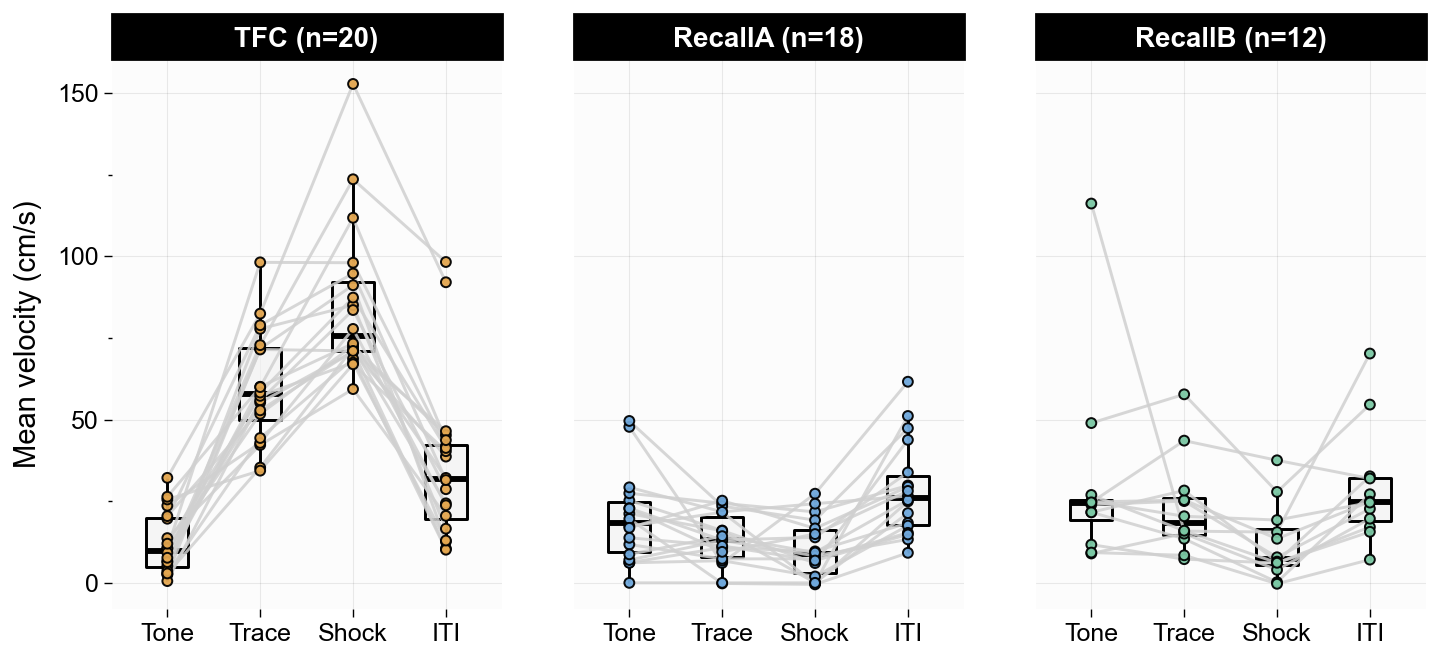

In [146]:
def plot_epoch_profiles_all_sessions(raw_df, name="epoch_profiles_included"):
    raw_epoch = raw_df.pivot_table(
        index=["session", "mouse_id", "cohort"], columns="epoch",
        values="mean_velocity", aggfunc="mean"
    ).reset_index()

    sessions = [s for s in ["TFC", "RecallA", "RecallB"]
                if s in raw_epoch["session"].unique()]
    rows = []

    for sess in sessions:
        d = raw_epoch[raw_epoch["session"] == sess].copy()
        has_shock = "Shock" in raw_df.loc[raw_df["session"] == sess, "epoch"].unique()
        epochs = ["ITI", "Tone", "Trace", "Shock"] if has_shock else ["ITI", "Tone", "Trace"]

        for _, row in d.iterrows():
            if classify_profile_row(row, epochs) != "included":
                continue
            for ep in epochs:
                rows.append({
                    "session": sess, "mouse_id": row["mouse_id"],
                    "epoch": ep, "velocity": row.get(ep, np.nan)
                })

    long_df = pd.DataFrame(rows).dropna(subset=["velocity"])
    long_df["session"] = pd.Categorical(
        long_df["session"], ["TFC", "RecallA", "RecallB"], ordered=True
    )
    long_df["epoch"] = pd.Categorical(
        long_df["epoch"], ["Tone", "Trace", "Shock","ITI"], ordered=True
    )

    n_df = long_df.groupby("session", observed=True)["mouse_id"].nunique().to_dict()
    long_df["session_label"] = long_df["session"].map(lambda s: f"{s} (n={n_df[s]})")
    label_order = [f"{s} (n={n_df[s]})" for s in sessions]
    long_df["session_label"] = pd.Categorical(
        long_df["session_label"], label_order, ordered=True
    )

    # Main appearance settings
    SESSION_COLORS = {
        "TFC": "#E3A64F",
        "RecallA": "#6FA8DC",
        "RecallB": "#7BC8A4"
    }
    LINE_COLOR = "#D0D0D0"   # matched lines
    DOT_EDGE = "#000000"      # dot outline
    BOX_EDGE = "#000000"      # box/whiskers
    BOX_FILL = "#F2F2F2"      # box interior
    PANEL_BG = "#FCFCFC"      # panel background

    p = (
        ggplot(long_df, aes("epoch", "velocity"))
        + geom_boxplot(
            width=.45, fill=BOX_FILL, alpha=.65, outlier_shape="",
            color=BOX_EDGE, size=.6
        )
        + geom_line(
            aes(group="mouse_id"), color=LINE_COLOR, alpha=.85, size=.6
        )
        + geom_point(
            aes(fill="session"), shape="o", size=1.6,
            stroke=.4, color=DOT_EDGE, alpha=.95
        )
        + facet_wrap("~session_label", scales="free_x", nrow=1)
        + scale_fill_manual(values=SESSION_COLORS)
        + labs(x="", y="Mean velocity (cm/s)", fill="")
        + theme_gray(base_family="Arial", base_size=11)
        + theme(
            figure_size=(7.2, 3.3), panel_spacing=.05, legend_position="none",
            panel_background=element_rect(fill=PANEL_BG, color="black", size=.6),
            panel_grid_major=element_line(color="black", alpha=.08, size=.4),
            panel_grid_minor=element_blank(),
            strip_background=element_rect(fill="black", color="black"),
            strip_text=element_text(color="white", weight="bold", size=10),
            axis_text=element_text(color="black", size=9),
            axis_title_y=element_text(color="black", size=10.5),
            axis_ticks=element_line(color="black", size=.5)
        )
    )

    p.save(OUTPUT_DIR / f"{name}.png", dpi=300, verbose=False)
    p.save(OUTPUT_DIR / f"{name}.svg", dpi=300, verbose=False)
    return p

plot_epoch_profiles_all_sessions(df)

In [147]:
from scipy.stats import ttest_rel
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests
from itertools import combinations

def epoch_stats_all_sessions(raw_df):
    raw_epoch = raw_df.pivot_table(
        index=["session", "mouse_id", "cohort"], columns="epoch",
        values="mean_velocity", aggfunc="mean"
    ).reset_index()

    omnibus, posthoc = [], []

    for sess in ["TFC", "RecallA", "RecallB"]:
        d = raw_epoch[raw_epoch["session"] == sess].copy()
        if d.empty:
            continue

        epochs = (["ITI", "Tone", "Trace", "Shock"]
                  if "Shock" in raw_df.loc[raw_df["session"] == sess, "epoch"].unique()
                  else ["ITI", "Tone", "Trace"])

        # Same threshold criterion as plot
        d = d[d.apply(lambda r: classify_profile_row(r, epochs) == "included", axis=1)]

        # Require complete data across epochs for repeated-measures stats
        d = d.dropna(subset=epochs)

        long = d.melt(
            id_vars=["mouse_id"], value_vars=epochs,
            var_name="epoch", value_name="velocity"
        )

        # Repeated-measures ANOVA
        fit = AnovaRM(long, "velocity", "mouse_id", within=["epoch"]).fit()
        a = fit.anova_table.iloc[0]

        omnibus.append({
            "session": sess,
            "n": len(d),
            "F": a["F Value"],
            "df_num": a["Num DF"],
            "df_den": a["Den DF"],
            "p": a["Pr > F"]
        })

        # Paired post-hoc comparisons
        session_tests = []
        for ep1, ep2 in combinations(epochs, 2):
            t, p = ttest_rel(d[ep1], d[ep2])
            session_tests.append({
                "session": sess, "comparison": f"{ep1} vs {ep2}",
                "n": len(d), "t": t, "p_raw": p
            })

        # Holm correction within session
        pvals = [x["p_raw"] for x in session_tests]
        corrected = multipletests(pvals, method="holm")[1]

        for result, p_adj in zip(session_tests, corrected):
            result["p_holm"] = p_adj
            posthoc.append(result)

    omnibus_df = pd.DataFrame(omnibus)
    posthoc_df = pd.DataFrame(posthoc)
    posthoc_df["p_raw"] = posthoc_df["p_raw"].map(lambda x: f"{x:.4f}")
    posthoc_df["p_holm"] = posthoc_df["p_holm"].map(lambda x: f"{x:.4f}")


    display(omnibus_df)
    display(posthoc_df)

    return omnibus_df, posthoc_df


epoch_anova, epoch_posthoc = epoch_stats_all_sessions(df)

,session,n,F,df_num,df_den,p
0,TFC,20,96.470755,3.0,57.0,2.581998e-22
1,RecallA,18,14.913664,3.0,51.0,4.275020e-07
2,RecallB,12,3.992207,3.0,33.0,1.569174e-02


,session,comparison,n,t,p_raw,p_holm
0,TFC,ITI vs Tone,20,4.911891,0.0001,0.0002
1,TFC,ITI vs Trace,20,-4.460183,0.0003,0.0003
2,TFC,ITI vs Shock,20,-13.741669,0.0000,0.0000
3,TFC,Tone vs Trace,20,-11.122983,0.0000,0.0000
4,TFC,Tone vs Shock,20,-15.594399,0.0000,0.0000
5,TFC,Trace vs Shock,20,-6.212368,0.0000,0.0000
6,RecallA,ITI vs Tone,18,2.881699,0.0104,0.0311
7,RecallA,ITI vs Trace,18,4.028489,0.0009,0.0044
8,RecallA,ITI vs Shock,18,5.921929,0.0000,0.0001
9,RecallA,Tone vs Trace,18,2.095299,0.0514,0.1029


## 2. Epoch mean velocity across sessions

All mice, by epoch, for each session
Dots = individual mice; error bars = SEM

Saved: /Users/suthardr/Desktop/mega_sheet/behavior_velocity_outputs/AllSessions_epoch_resolved_velocity.png
Saved: /Users/suthardr/Desktop/mega_sheet/behavior_velocity_outputs/AllSessions_epoch_resolved_velocity.pdf


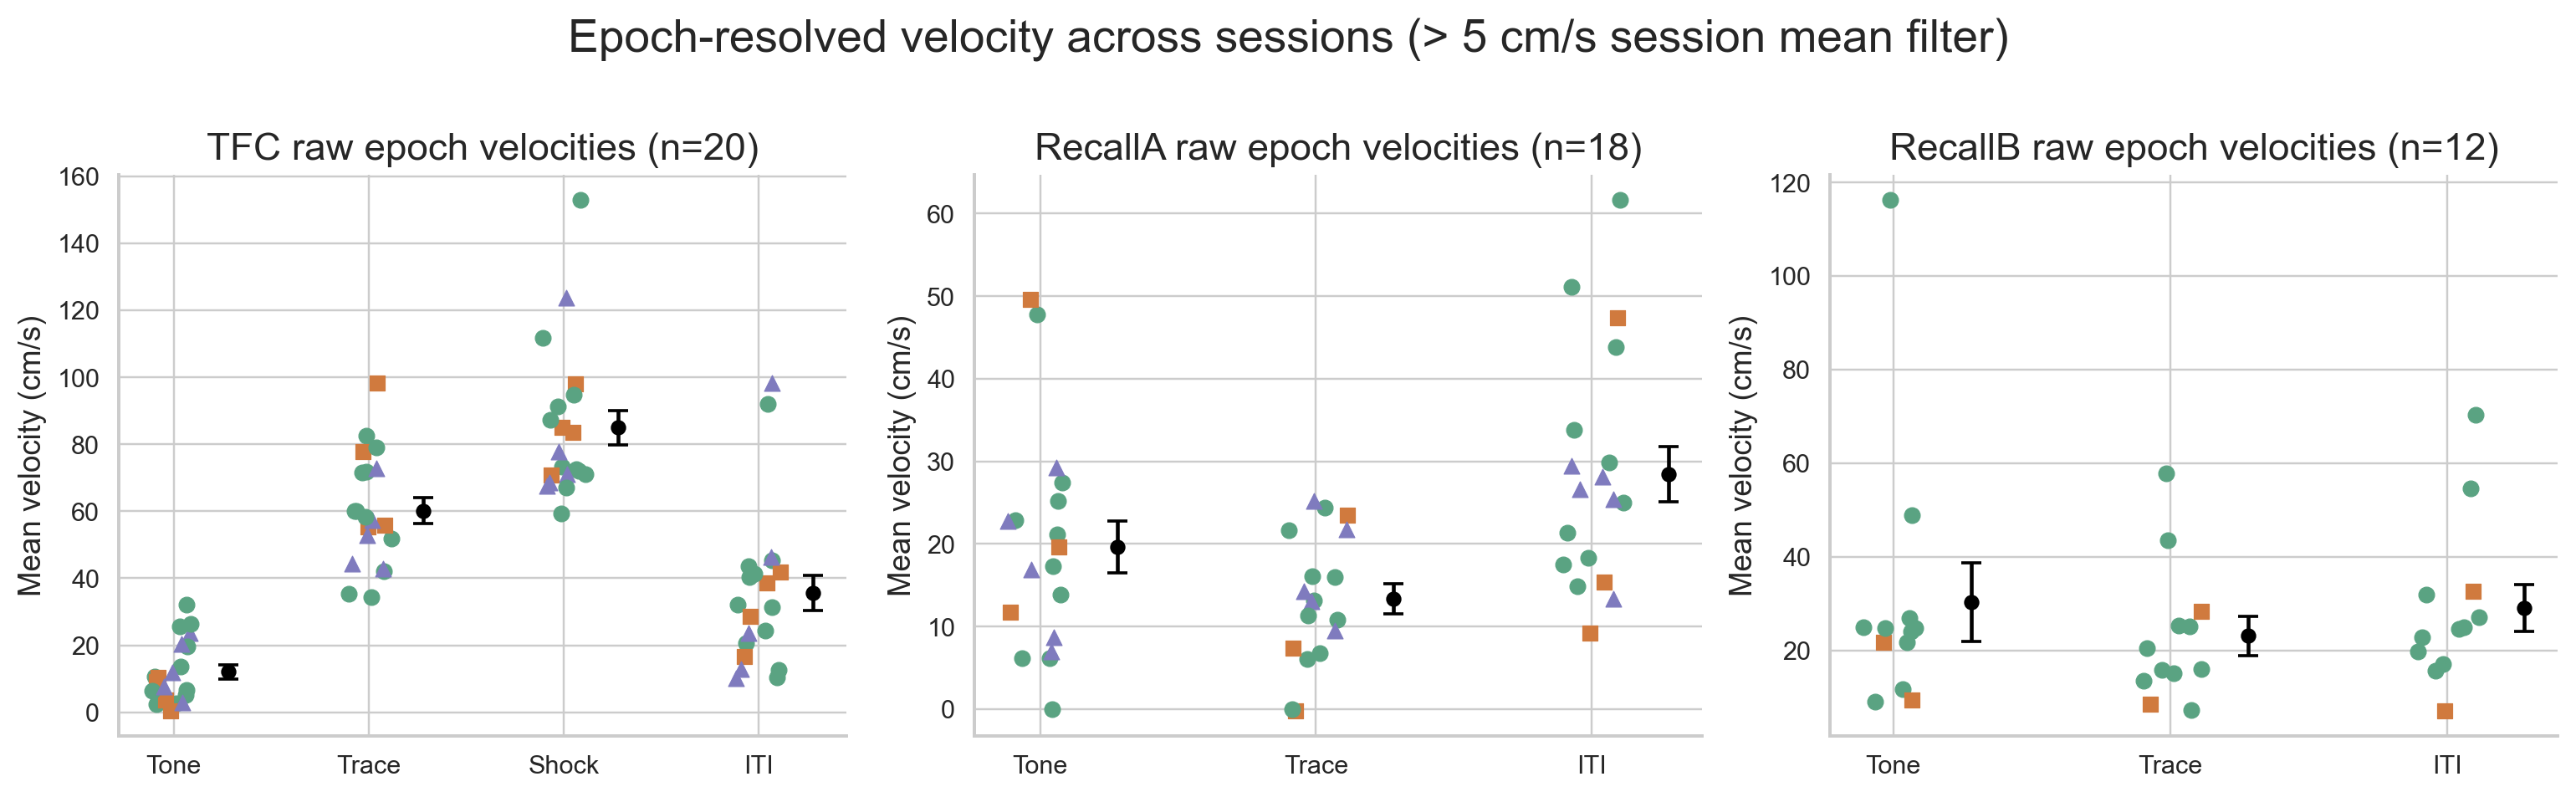

In [148]:
def plot_epoch_resolved_velocity():
    session_order = [s for s in ["TFC", "RecallA", "RecallB"] if s in epoch_tbl["session"].unique()]
    fig, axes = plt.subplots(1, len(session_order), figsize=(4.7 * len(session_order), 4.2), dpi=220)
    if len(session_order) == 1:
        axes = [axes]

    for ax, sess in zip(axes, session_order):
        d = epoch_tbl[epoch_tbl["session"] == sess].copy()
        epoch_order = ["Tone", "Trace", "Shock", "ITI"] if sess == "TFC" else ["Tone", "Trace", "ITI"]
        epoch_order = [ep for ep in epoch_order if ep in d.columns and d[ep].notna().any()]
        xpos = np.arange(1, len(epoch_order) + 1)
        rng = np.random.default_rng(42)
        for _, row in d.iterrows():
            sty = COHORT_STYLES.get(row["cohort"], dict(color="#666666", marker="o"))
            for i, ep in enumerate(epoch_order):
                val = row.get(ep, np.nan)
                if pd.notna(val):
                    ax.scatter(xpos[i] + rng.uniform(-0.12, 0.12), val, s=38, c=sty["color"],
                               marker=sty["marker"], edgecolors=sty["color"], linewidths=0.4, zorder=3)
        for i, ep in enumerate(epoch_order):
            add_mean_sem(ax, xpos[i] + 0.28, d[ep].dropna().values)
        ax.set_xticks(xpos); ax.set_xticklabels(epoch_order)
        ax.set_title(f"{sess} raw epoch velocities (n={len(d)})")
        ax.set_ylabel("Mean velocity (cm/s)")
        style_ax(ax)

    fig.suptitle(f"Epoch-resolved velocity across sessions (> {SESSION_MEAN_THRESHOLD:g} cm/s session mean filter)", fontsize=18, y=1.02)
    plt.tight_layout()
    save_fig(fig, "AllSessions_epoch_resolved_velocity")

plot_epoch_resolved_velocity()

## 3. Tone, Trace, and Tone+Trace vs ITI side-by-side

RecallA and RecallB
Epoch (Tone, Trace, Tone+Trace vs ITI)

,session,comparison,n,target_mean,ITI_mean,t,p
0,RecallA,Tone vs ITI,18,19.65,28.45,-2.882,0.0104
1,RecallA,Trace vs ITI,18,13.37,28.45,-4.028,0.0009
2,RecallA,Tone+Trace vs ITI,18,16.51,28.45,-3.890,0.0012
3,RecallB,Tone vs ITI,12,30.31,29.03,0.289,0.7778
4,RecallB,Trace vs ITI,12,23.05,29.03,-1.250,0.2373
5,RecallB,Tone+Trace vs ITI,12,26.68,29.03,-1.645,0.1282


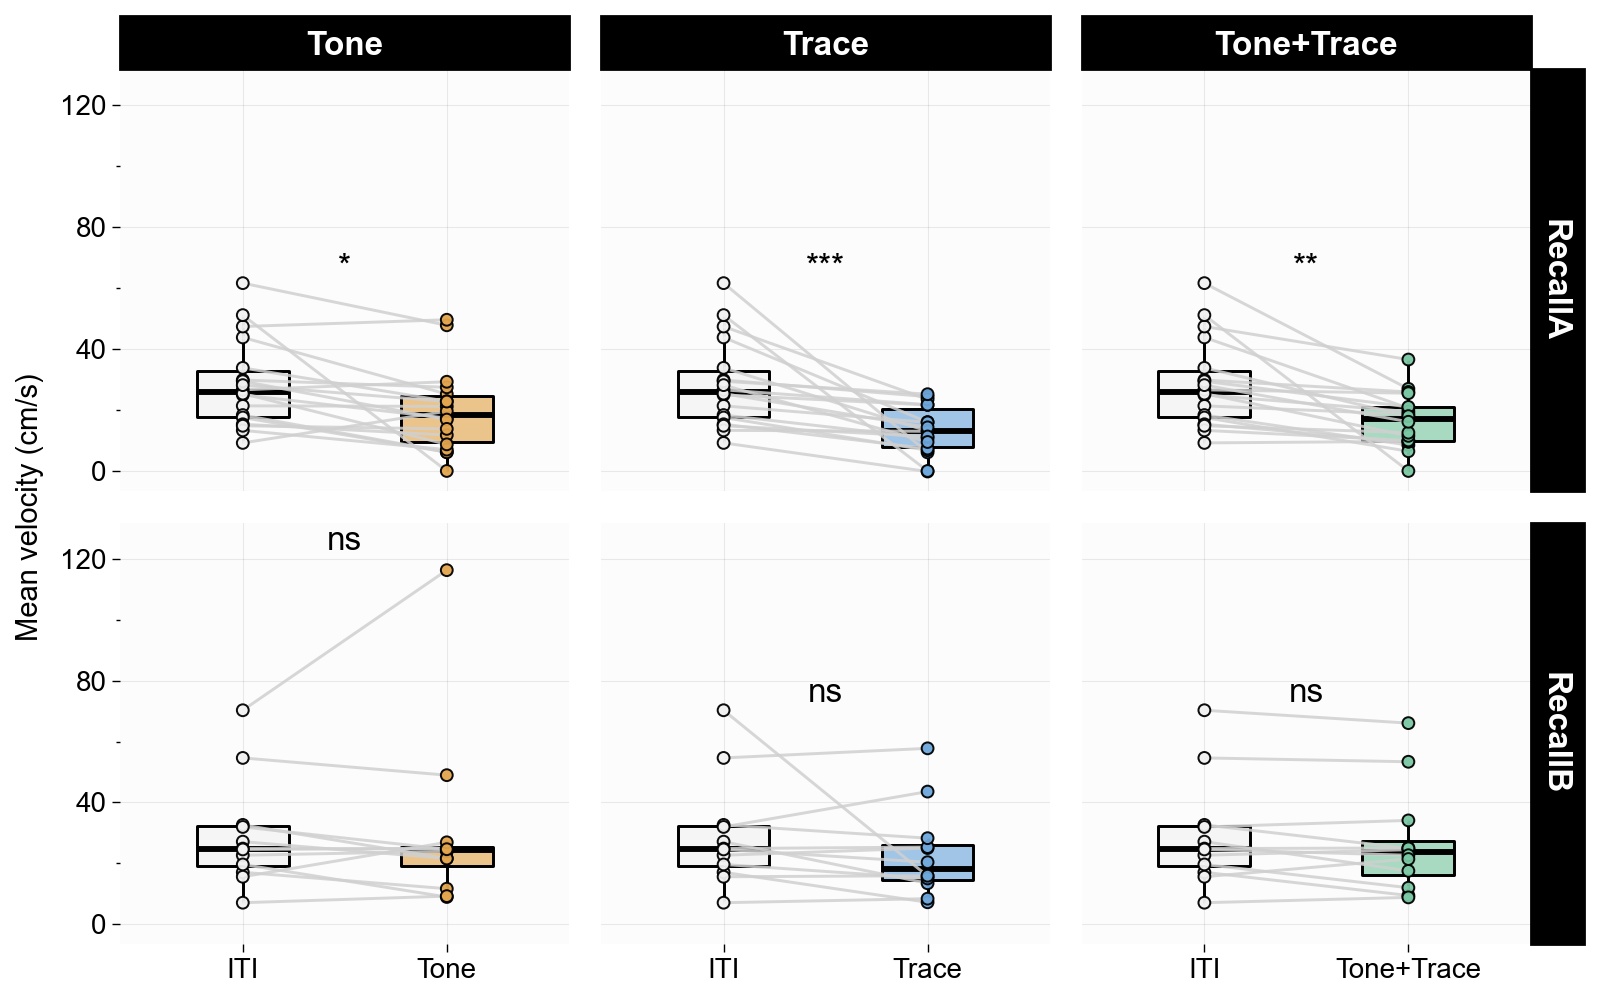

In [149]:
from plotnine import (
    ggplot, aes, geom_boxplot, geom_line, geom_point, geom_text,
    facet_grid, theme_gray, theme, labs, scale_fill_manual,
    element_text, element_rect, element_line, element_blank
)
from scipy.stats import ttest_rel

def plot_side_by_side_tone_trace_tonetrace():
    stats_rows, rows = [], []
    comparisons = [("Tone", "Tone"), ("Trace", "Trace"), ("ToneTrace", "Tone+Trace")]

    for sess in ["RecallA", "RecallB"]:
        d = recall_tbl[recall_tbl["session"] == sess].copy()
        if d.empty:
            continue

        for col, label in comparisons:
            dd = d[["mouse_id", col, "ITI"]].dropna()
            y1, y2 = dd[col].astype(float), dd["ITI"].astype(float)
            t, p = ttest_rel(y1, y2) if len(dd) > 1 else (np.nan, np.nan)

            stats_rows.append({
                "session": sess, "comparison": f"{label} vs ITI", "n": len(dd),
                "target_mean": y1.mean(), "ITI_mean": y2.mean(),
                "t": t, "p": p
            })

            for _, r in dd.iterrows():
                rows += [
                    {"session": sess, "panel": label, "mouse_id": r["mouse_id"],
                     "group": label, "velocity": r[col]},
                    {"session": sess, "panel": label, "mouse_id": r["mouse_id"],
                     "group": "ITI", "velocity": r["ITI"]}
                ]

    long_df = pd.DataFrame(rows)
    stats = pd.DataFrame(stats_rows)

    long_df["session"] = pd.Categorical(
        long_df["session"], ["RecallA", "RecallB"], ordered=True
    )
    long_df["panel"] = pd.Categorical(
        long_df["panel"], ["Tone", "Trace", "Tone+Trace"], ordered=True
    )

    def p_label(p):
        if pd.isna(p):
            return ""
        if p < .0001: return "****"
        if p < .001: return "***"
        if p < .01: return "**"
        if p < .05: return "*"
        return "ns"

    label_df = (
        long_df.groupby(["session", "panel"], observed=True)["velocity"]
        .max().reset_index(name="y")
        .merge(stats[["session", "comparison", "p"]], on="session")
    )
    label_df["comparison_panel"] = label_df["comparison"].str.replace(" vs ITI", "", regex=False)
    label_df = label_df[label_df["panel"].astype(str) == label_df["comparison_panel"]].copy()
    label_df["label"] = label_df["p"].apply(p_label)
    label_df["x"] = 1.5
    label_df["y"] *= 1.08

    COLORS = {
        "Tone": "#E3A64F",
        "Trace": "#6FA8DC",
        "Tone+Trace": "#7BC8A4",
        "ITI": "#F2F2F2"
    }

    p = (
        ggplot(long_df, aes("group", "velocity"))
        + geom_boxplot(
            aes(fill="group"), width=.45, alpha=.65,
            outlier_shape="", color="black", size=.6
        )
        + geom_line(
            aes(group="mouse_id"), color="#D0D0D0",
            alpha=.85, size=.6
        )
        + geom_point(
            aes(fill="group"), shape="o", size=2,
            stroke=.4, color="black", alpha=.95
        )
        + geom_text(
            label_df, aes("x", "y", label="label"),
            inherit_aes=False, size=12, color="black"
        )
        + facet_grid("session ~ panel", scales="free_x")
        + scale_fill_manual(values=COLORS)
        + labs(x="", y="Mean velocity (cm/s)", fill="")
        + theme_gray(base_family="Arial", base_size=12)
        + theme(
            figure_size=(8, 5), panel_spacing=.02, legend_position="none",
            panel_background=element_rect(fill="#FCFCFC", color="black", size=.6),
            panel_grid_major=element_line(color="black", alpha=.08, size=.4),
            panel_grid_minor=element_blank(),
            strip_background=element_rect(fill="black", color="black"),
            strip_text=element_text(color="white", weight="bold", size=12),
            axis_text=element_text(color="black", size=10),
            axis_title_y=element_text(color="black", size=10.5),
            axis_ticks=element_line(color="black", size=.5)
        )
    )

    p.save(
        OUTPUT_DIR / "RecallA_RecallB_Tone_Trace_ToneTrace_vs_ITI_allmice.png",
        dpi=300, verbose=False
    )
    p.save(
        OUTPUT_DIR / "RecallA_RecallB_Tone_Trace_ToneTrace_vs_ITI_allmice.svg",
        dpi=300, verbose=False
    )

    stats.to_csv(
        OUTPUT_DIR / "RecallA_RecallB_Tone_Trace_ToneTrace_vs_ITI_stats_allmice.csv",
        index=False
    )

    display(stats.style.format({
        "target_mean": "{:.2f}", "ITI_mean": "{:.2f}",
        "t": "{:.3f}", "p": "{:.4f}"
    }))

    return p

plot_side_by_side_tone_trace_tonetrace()

Saved: /Users/suthardr/Desktop/amithi/behavior_velocity_outputs/RecallA_RecallB_Tone_Trace_ToneTrace_vs_ITI_allmice.png
Saved: /Users/suthardr/Desktop/amithi/behavior_velocity_outputs/RecallA_RecallB_Tone_Trace_ToneTrace_vs_ITI_allmice.pdf


,comparison,n,target_mean,target_sem,ITI_mean,ITI_sem,ratio_mean,ratio_sem,ITI_minus_target_mean,ITI_minus_target_sem,paired_t_p,session
0,Tone vs ITI,7,21.619979,5.406664,31.067609,6.121230,0.663747,0.097477,9.447629,2.455380,0.008482,RecallA
1,Trace vs ITI,7,14.529562,2.658556,31.067609,6.121230,0.553115,0.106411,16.538047,7.206465,0.061530,RecallA
2,Tone+Trace vs ITI,7,18.074771,2.990051,31.067609,6.121230,0.608431,0.083408,12.992838,4.446510,0.026561,RecallA
3,Tone vs ITI,7,36.610310,14.136260,33.767010,7.695602,0.934645,0.141994,-2.843300,7.338670,0.711801,RecallB
4,Trace vs ITI,7,22.840848,6.304224,33.767010,7.695602,0.727921,0.132192,10.926162,7.625971,0.201905,RecallB
5,Tone+Trace vs ITI,7,29.725579,8.158181,33.767010,7.695602,0.831283,0.082317,4.041431,1.665268,0.051379,RecallB


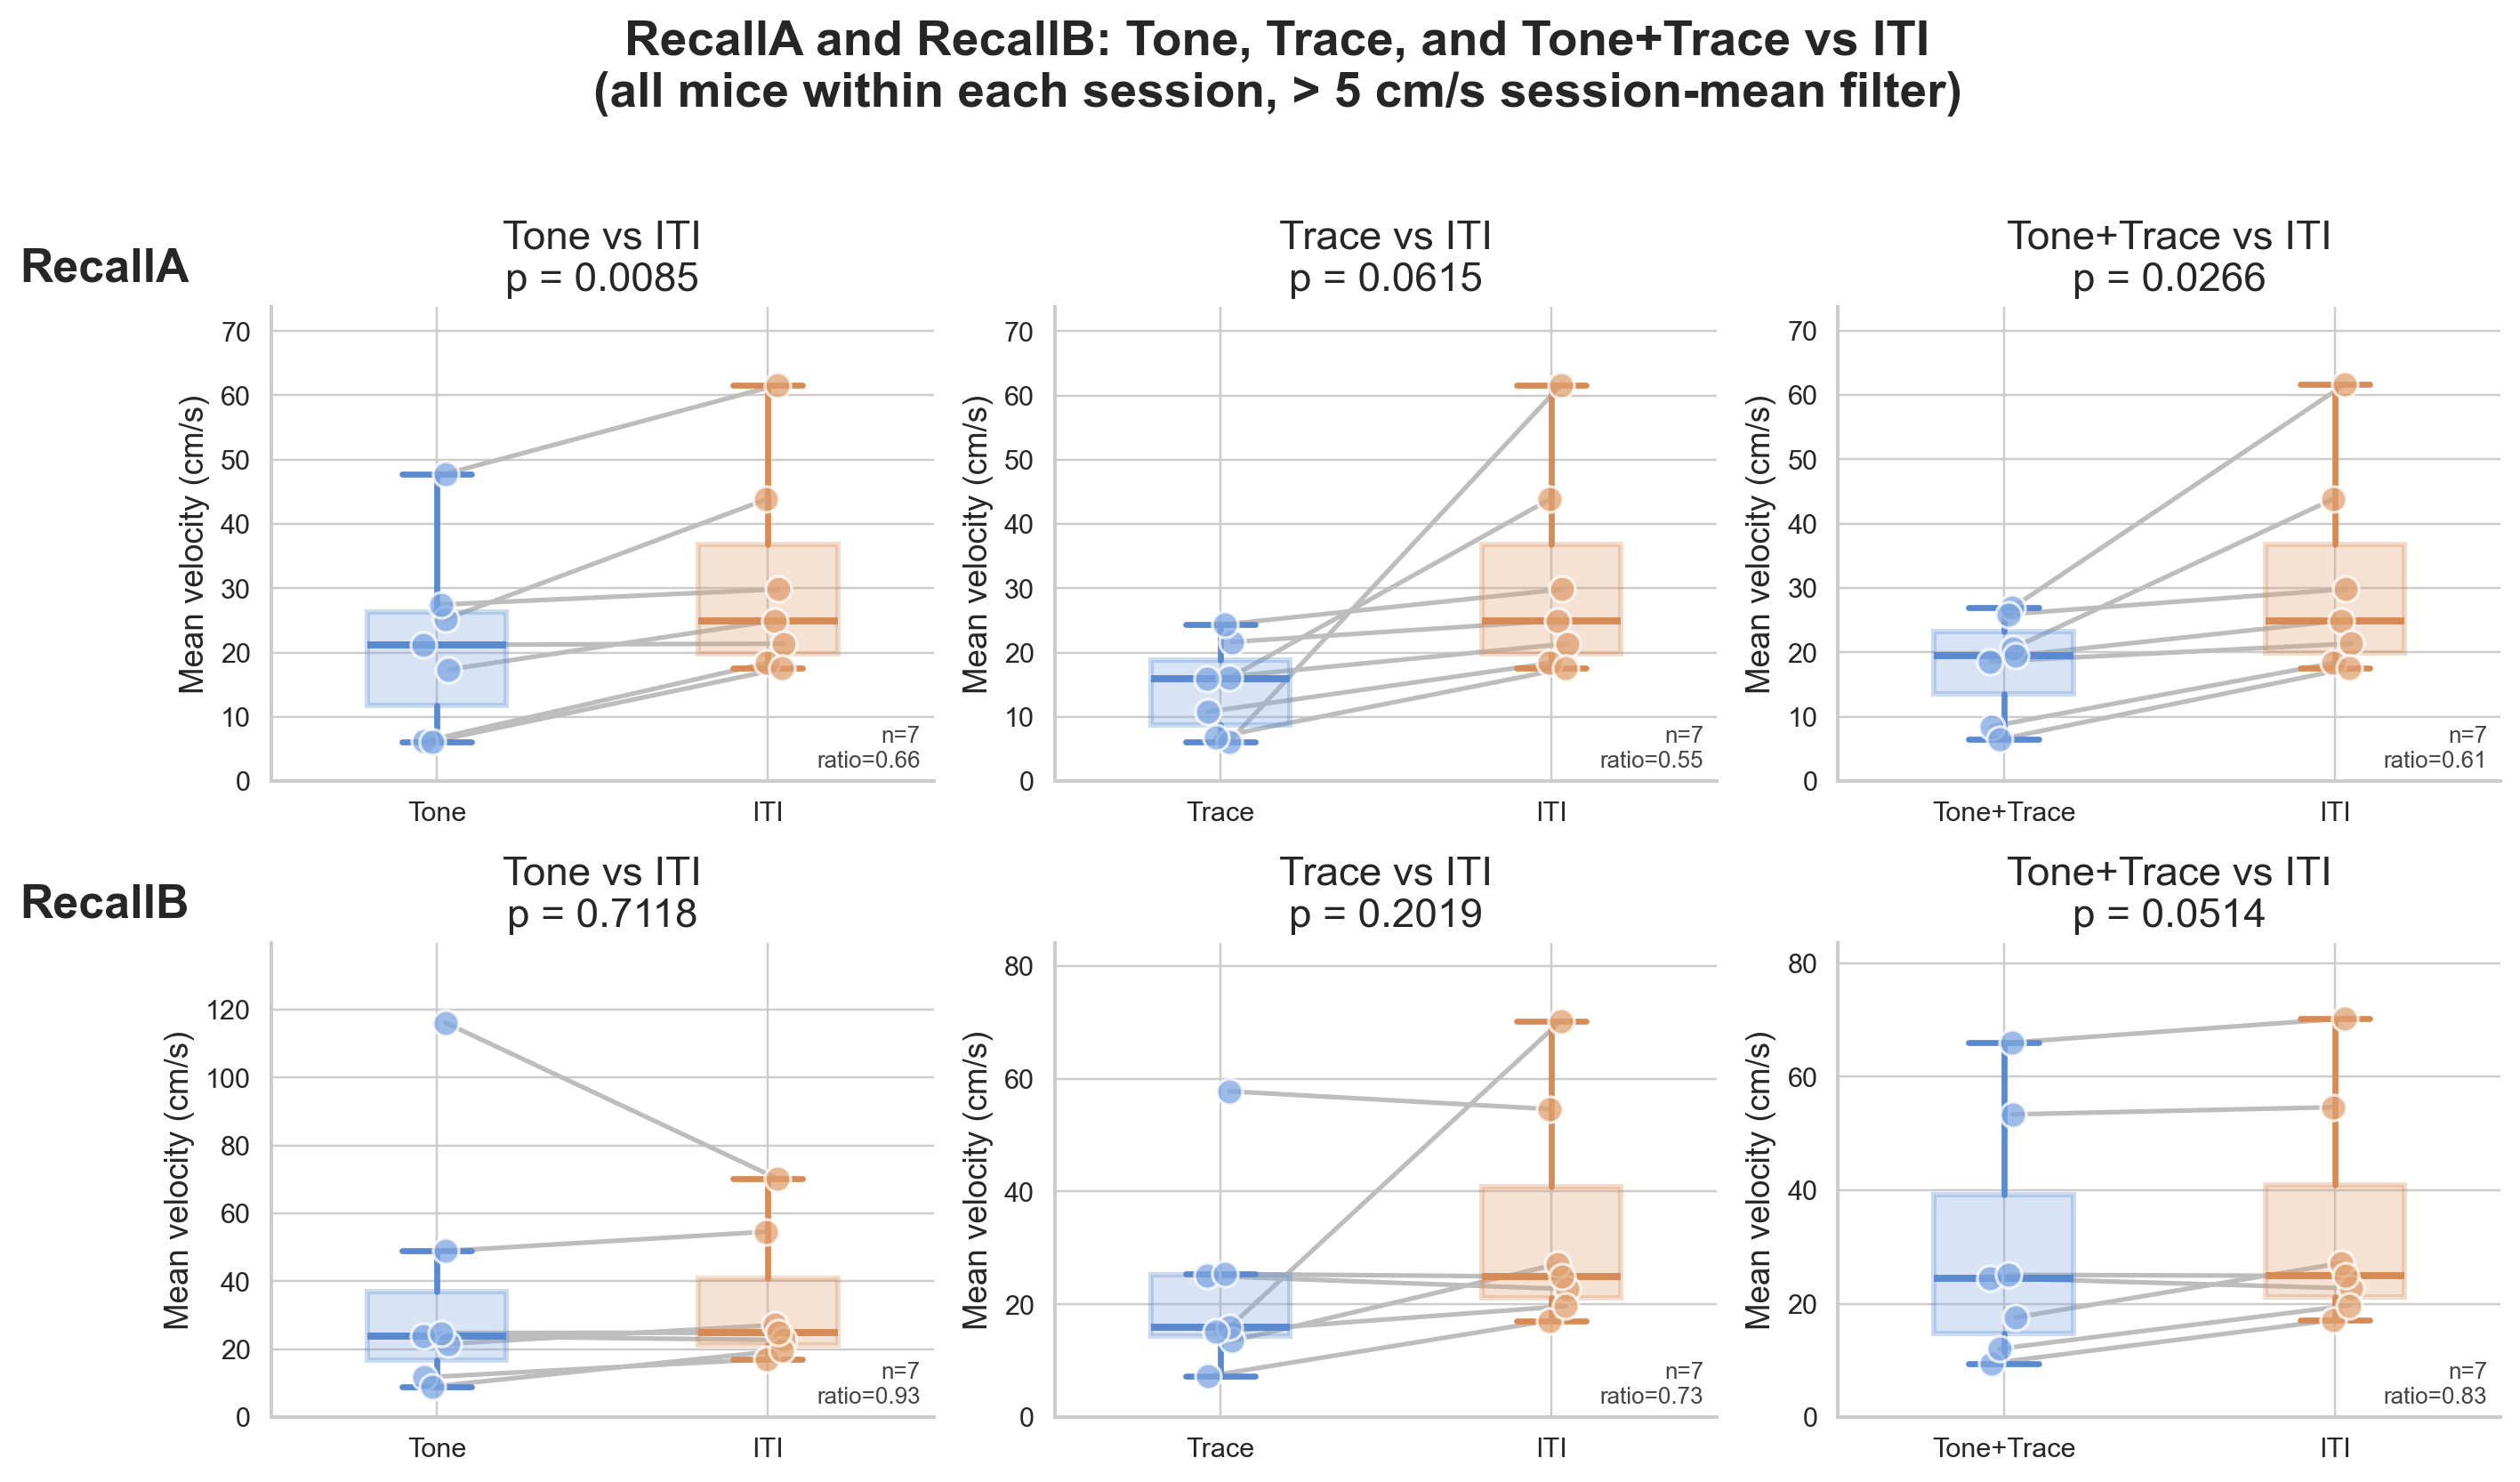

In [124]:
def plot_side_by_side_tone_trace_tonetrace():
    stats_rows = []
    fig, axes = plt.subplots(2, 3, figsize=(12.8, 7.6), dpi=220)

    for r, sess in enumerate(["RecallA", "RecallB"]):
        d = recall_tbl[recall_tbl["session"] == sess].copy()
        if len(d) == 0:
            continue
        for c, (col, label) in enumerate([("Tone", "Tone"), ("Trace", "Trace"), ("ToneTrace", "Tone+Trace")]):
            row_stats = paired_box_panel(axes[r, c], d, col, label, p_label=True)
            row_stats["session"] = sess
            stats_rows.append(row_stats)
        axes[r, 0].text(-0.38, 1.08, sess, transform=axes[r, 0].transAxes, fontsize=17, fontweight="bold", va="center")

    fig.suptitle(
        f"RecallA and RecallB: Tone, Trace, and Tone+Trace vs ITI\n"
        f"(all mice within each session, > {SESSION_MEAN_THRESHOLD:g} cm/s session-mean filter)",
        fontsize=18, fontweight="bold", y=0.99
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    save_fig(fig, "RecallA_RecallB_Tone_Trace_ToneTrace_vs_ITI_allmice")

    stats = pd.DataFrame(stats_rows)
    stats.to_csv(OUTPUT_DIR / "RecallA_RecallB_Tone_Trace_ToneTrace_vs_ITI_stats_allmice.csv", index=False)
    display(stats)

plot_side_by_side_tone_trace_tonetrace()

## 4. Trace alone vs ITI

This figure isolates the trace interval. In the current dataset this has been the cleanest RecallA effect.

Saved: /Users/suthardr/Desktop/amithi/behavior_velocity_outputs/RecallA_RecallB_ToneTrace_vs_ITI_allmice_mainplot.png
Saved: /Users/suthardr/Desktop/amithi/behavior_velocity_outputs/RecallA_RecallB_ToneTrace_vs_ITI_allmice_mainplot.pdf


,comparison,n,target_mean,target_sem,ITI_mean,ITI_sem,ratio_mean,ratio_sem,ITI_minus_target_mean,ITI_minus_target_sem,paired_t_p,session
0,ToneTrace vs ITI,7,18.074771,2.990051,31.067609,6.121230,0.608431,0.083408,12.992838,4.446510,0.026561,RecallA
1,ToneTrace vs ITI,7,29.725579,8.158181,33.767010,7.695602,0.831283,0.082317,4.041431,1.665268,0.051379,RecallB


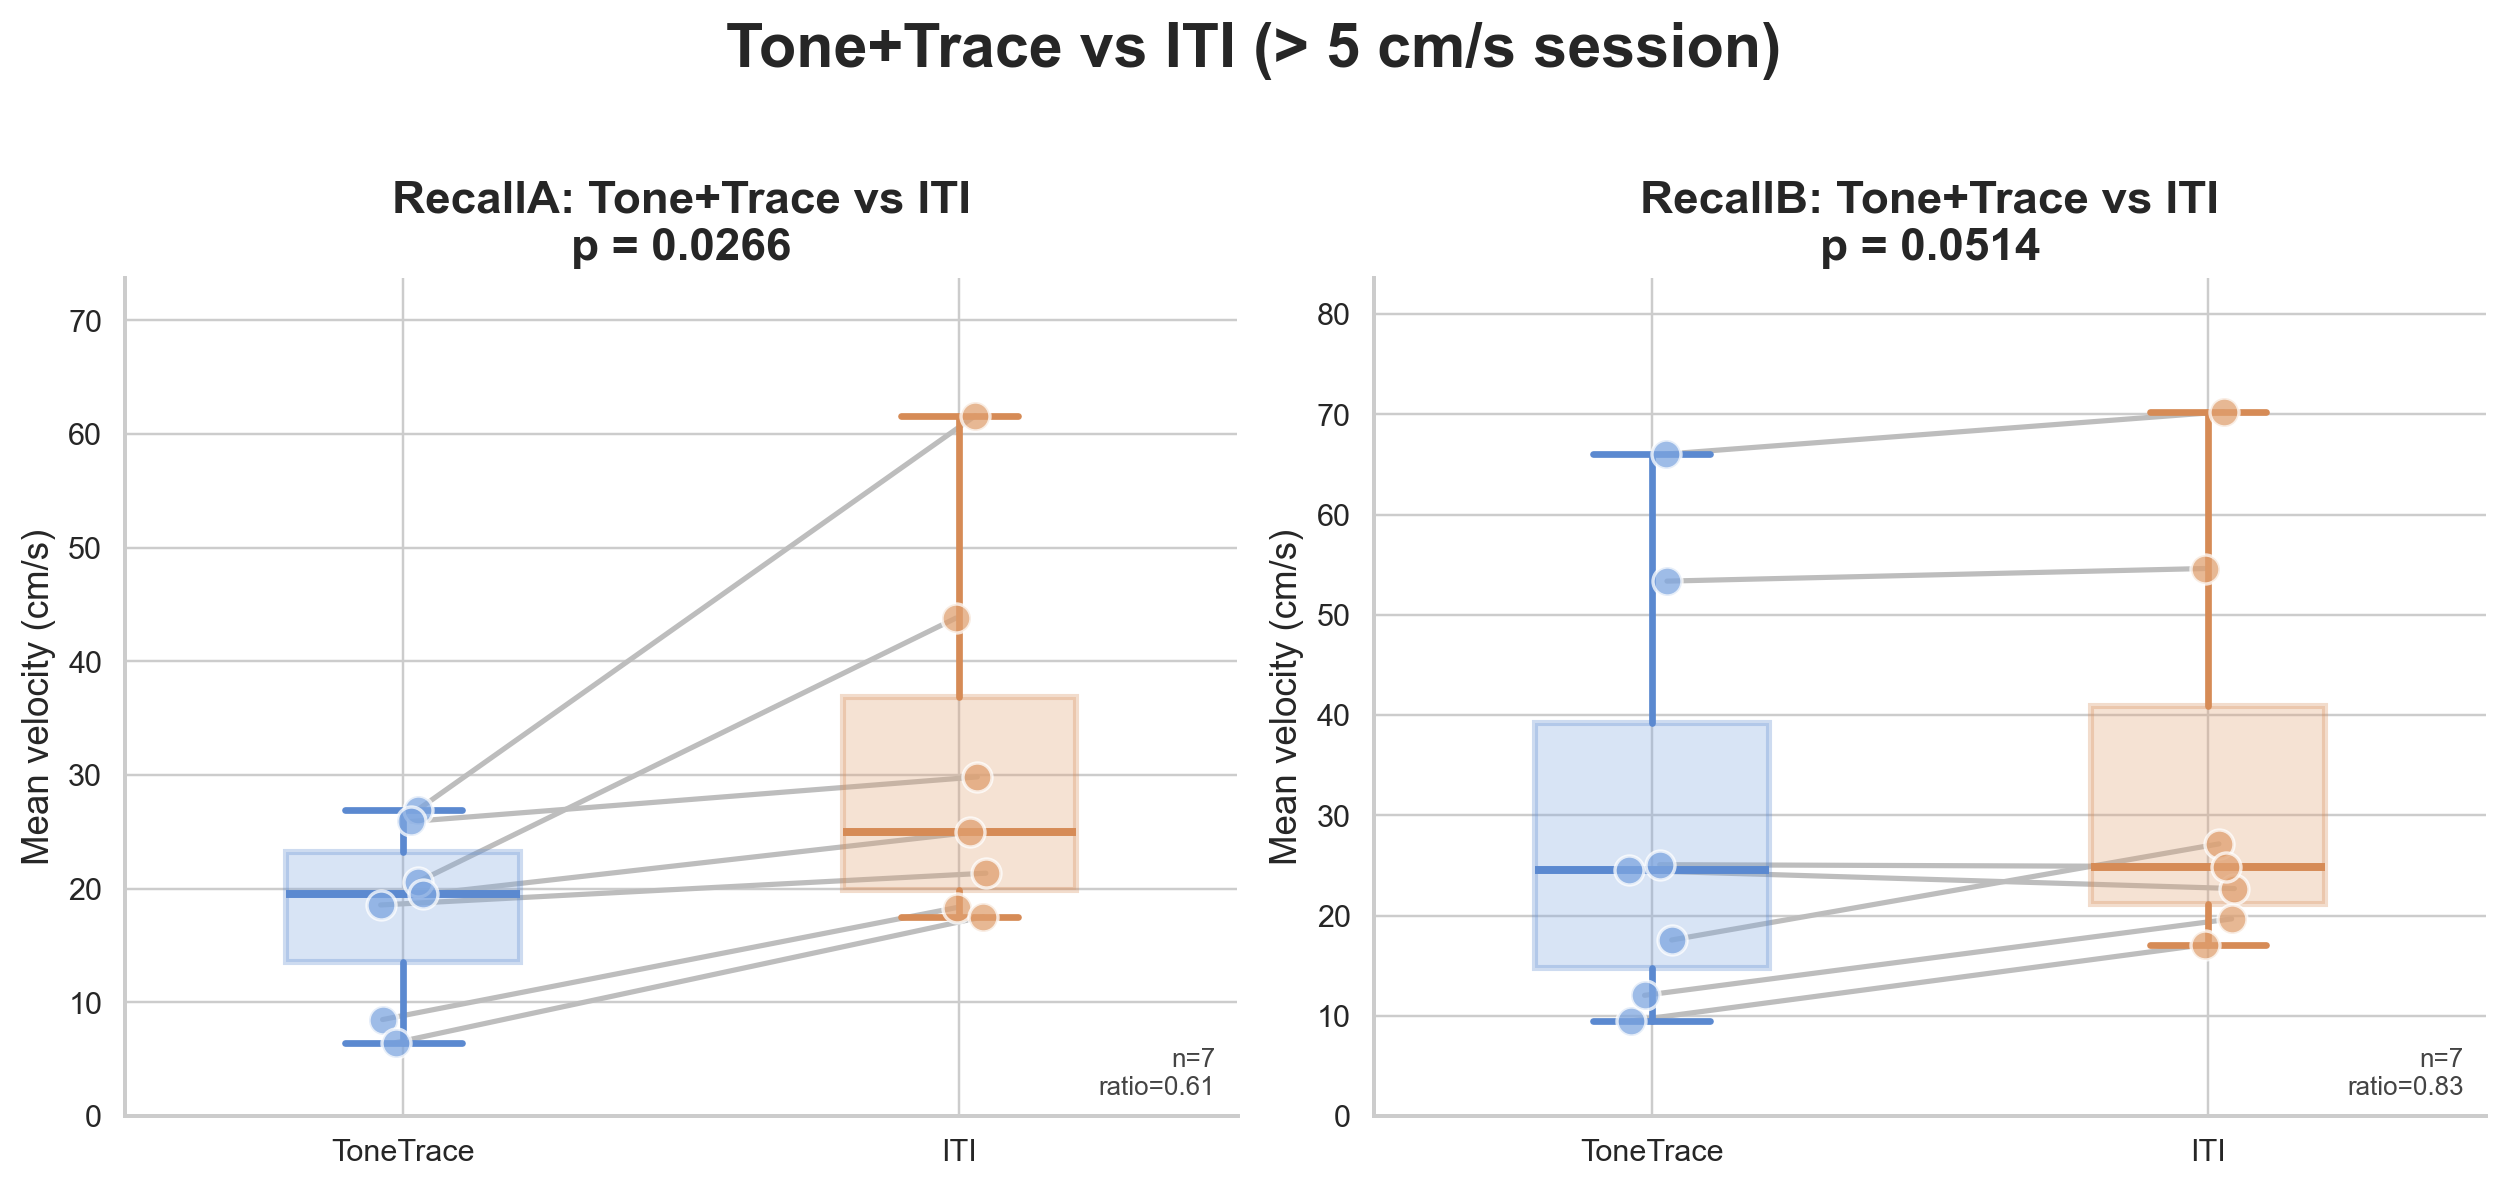

In [125]:

def plot_trace_vs_iti_combined():
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2), dpi=220)
    stats = []

    for ax, sess in zip(axes, ["RecallA", "RecallB"]):
        d = recall_tbl[recall_tbl["session"] == sess].copy()
        if len(d) == 0:
            continue
        row_stats = paired_box_panel(ax, d, "ToneTrace", "ToneTrace", p_label=True)
        row_stats["session"] = sess
        stats.append(row_stats)
        ax.set_title(f"{sess}: Tone+Trace vs ITI\np = {row_stats['paired_t_p']:.4f}", fontweight="bold")

    fig.suptitle(f"Tone+Trace vs ITI (> {SESSION_MEAN_THRESHOLD:g} cm/s session)", fontsize=20, fontweight="bold", y=1.03)
    plt.tight_layout()
    save_fig(fig, "RecallA_RecallB_ToneTrace_vs_ITI_allmice_mainplot")
    pd.DataFrame(stats).to_csv(OUTPUT_DIR / "RecallA_RecallB_ToneTrace_vs_ITI_stats_allmice.csv", index=False)
    display(pd.DataFrame(stats))

plot_trace_vs_iti_combined()

## 5. Matched-mouse RecallA → RecallB

Only mice that passed the 5cm/s threshold for BOTH recall A and B

Saved: /Users/suthardr/Desktop/mega_sheet/behavior_velocity_outputs/RecallA_RecallB_ToneTrace_vs_ITI_allmice_mainplot.png
Saved: /Users/suthardr/Desktop/mega_sheet/behavior_velocity_outputs/RecallA_RecallB_ToneTrace_vs_ITI_allmice_mainplot.svg


,comparison,session,n,target_mean,ITI_mean,ratio_mean,paired_t_p
0,ToneTrace vs ITI,RecallA,18,16.507888,28.450422,0.641146,0.001177
1,ToneTrace vs ITI,RecallB,12,26.681591,29.029439,0.932514,0.128211


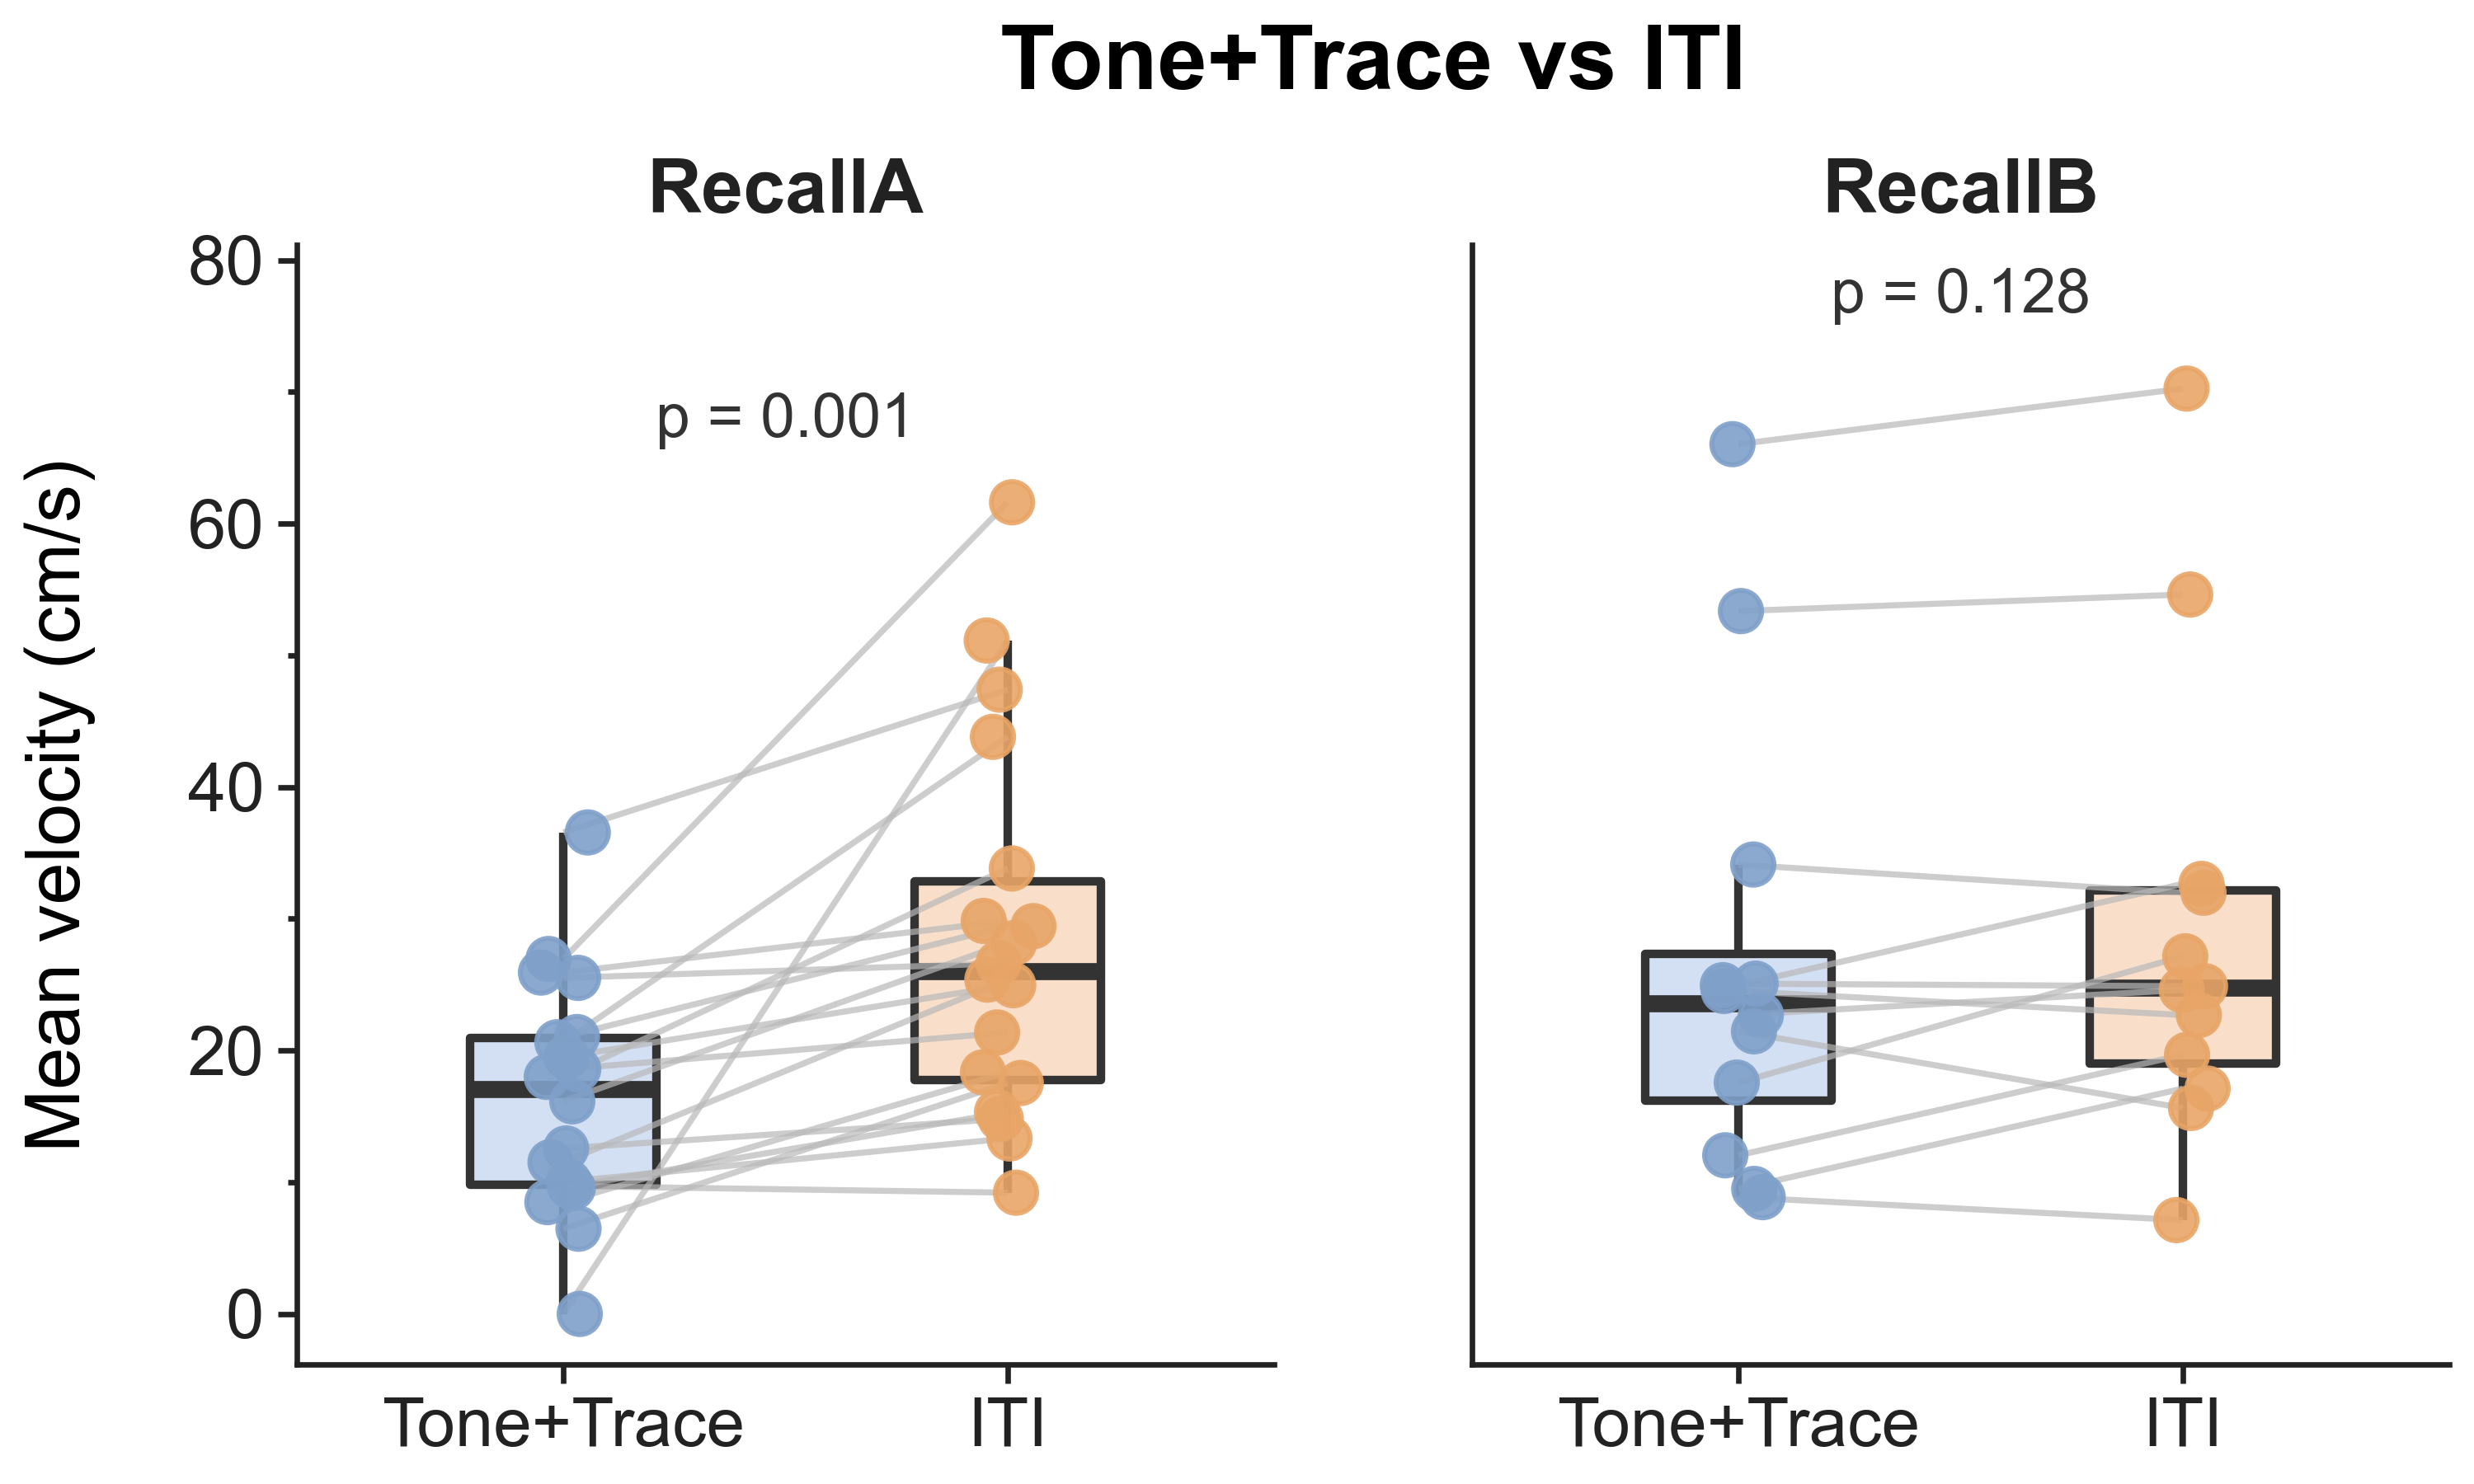

In [150]:
from plotnine import (
    ggplot, aes, geom_boxplot, geom_jitter, geom_line, geom_text,
    facet_wrap, theme_classic, theme, labs, scale_fill_manual, scale_color_manual,
    element_text, element_blank, element_line,
)
def plot_trace_vs_iti_combined_plotnine():

    J_TRACE_COLOR, J_TRACE_EDGE = "#AFC6E8", "#7FA0C9"
    J_ITI_COLOR, J_ITI_EDGE = "#F5C6A0", "#E8A567"

    stats = []
    long_rows = []

    for sess in ["RecallA", "RecallB"]:
        d = recall_tbl[recall_tbl["session"] == sess].copy()
        if len(d) == 0:
            continue
        y1 = d["ToneTrace"].astype(float).values
        y2 = d["ITI"].astype(float).values
        n = len(d)
        t_p = ttest_rel(y1, y2).pvalue if n > 1 else np.nan
        stats.append({
            "comparison": "ToneTrace vs ITI", "session": sess, "n": n,
            "target_mean": float(np.nanmean(y1)), "ITI_mean": float(np.nanmean(y2)),
            "ratio_mean": float(np.nanmean(y1 / y2)), "paired_t_p": float(t_p),
        })
        for _, row in d.iterrows():
            long_rows.append({"mouse_id": row["mouse_id"], "session": sess, "group": "Tone+Trace", "velocity": row["ToneTrace"]})
            long_rows.append({"mouse_id": row["mouse_id"], "session": sess, "group": "ITI", "velocity": row["ITI"]})

    long_df = pd.DataFrame(long_rows)
    long_df["group"] = pd.Categorical(long_df["group"], categories=["Tone+Trace", "ITI"], ordered=True)
    stats_df = pd.DataFrame(stats)

    # Position the p-value label near the top of each facet
    label_df = stats_df.merge(
        long_df.groupby("session")["velocity"].max().rename("y_max").reset_index(),
        on="session",
    )
    def p_label(p):
        return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    label_df["label"] = label_df["paired_t_p"].apply(p_label)
    label_df["x"] = 1.5
    label_df["y"] = label_df["y_max"] * 1.10

    p = (
        ggplot(long_df, aes(x="group", y="velocity"))
        + geom_boxplot(aes(fill="group"), width=0.42, outlier_shape="", alpha=0.55,
                        size=0.7, color="#333333")
        + geom_line(aes(group="mouse_id"), color="#B8B8B8", alpha=0.7, size=0.5)
        + geom_jitter(aes(color="group"), width=0.06, size=3, alpha=0.9, stroke=0.4)
        + geom_text(data=label_df, mapping=aes(x="x", y="y", label="label"),
                    inherit_aes=False, size=9, family="Arial", color="#333333")
        + facet_wrap("~session")
        + scale_fill_manual(values={"Tone+Trace": J_TRACE_COLOR, "ITI": J_ITI_COLOR})
        + scale_color_manual(values={"Tone+Trace": J_TRACE_EDGE, "ITI": J_ITI_EDGE})
        + labs(title="Tone+Trace vs ITI", x="", y="Mean velocity (cm/s)")
        + theme_classic(base_family="Arial", base_size=11)
        + theme(
            figure_size=(5, 3),
            dpi=300,
            plot_title=element_text(weight="bold", size=13, ha="center", margin={"b": 10}),
            axis_title_y=element_text(size=11, margin={"r": 8}),
            axis_text=element_text(size=10, color="#222222"),
            axis_line=element_line(color="#222222", size=0.8),
            axis_ticks=element_line(color="#222222", size=0.8),
            strip_background=element_blank(),
            strip_text=element_text(size=11, weight="bold", color="#222222"),
            panel_spacing=0.08,
            legend_position="none",
            panel_grid=element_blank(),
        )
    )

    png_path = OUTPUT_DIR / "RecallA_RecallB_ToneTrace_vs_ITI_allmice_mainplot.png"
    svg_path = OUTPUT_DIR / "RecallA_RecallB_ToneTrace_vs_ITI_allmice_mainplot.svg"
    p.save(png_path, dpi=300, verbose=False)
    p.save(svg_path, dpi=300, verbose=False)
    print("Saved:", png_path)
    print("Saved:", svg_path)

    stats_df.to_csv(OUTPUT_DIR / "RecallA_RecallB_ToneTrace_vs_ITI_stats_allmice.csv", index=False)
    display(stats_df)
    return p

plot_trace_vs_iti_combined_plotnine()



,comparison,session,n,target_mean,ITI_mean,ratio_mean,paired_t_p
0,ToneTrace vs ITI,RecallA,7,18.074771,31.067609,0.608431,0.026561
1,ToneTrace vs ITI,RecallB,7,29.725579,33.767010,0.831283,0.051379


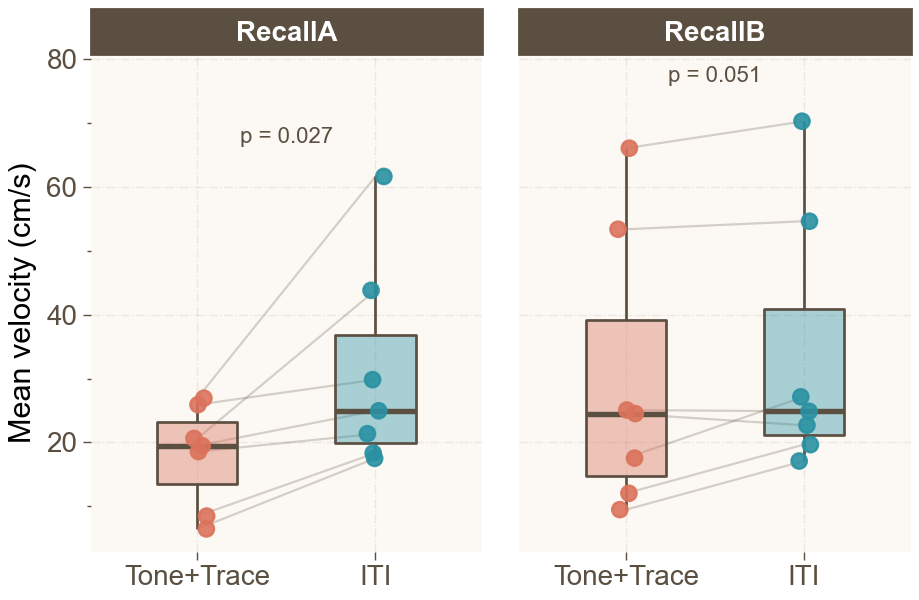

In [126]:
from plotnine import (
    ggplot, aes, geom_boxplot, geom_jitter, geom_line, geom_text,
    facet_wrap, theme_gray, theme, labs,
    scale_color_manual,
    element_text, element_blank, element_line, element_rect,
)
def plot_trace_vs_iti_combined_plotnine():
    TRACE_COLOR, ITI_COLOR = "#DB735C", "#2A91A2"
    TEXT_COLOR, BG_COLOR = "#5B4F41", "#FCF9F4"

    stats, long_rows = [], []

    for sess in ["RecallA", "RecallB"]:
        d = recall_tbl[recall_tbl["session"] == sess].copy()
        if d.empty:
            continue

        y1, y2 = d["ToneTrace"].astype(float).values, d["ITI"].astype(float).values
        t_p = ttest_rel(y1, y2).pvalue if len(d) > 1 else np.nan

        stats.append({
            "comparison": "ToneTrace vs ITI", "session": sess, "n": len(d),
            "target_mean": np.nanmean(y1), "ITI_mean": np.nanmean(y2),
            "ratio_mean": np.nanmean(y1 / y2), "paired_t_p": t_p
        })

        for _, row in d.iterrows():
            long_rows += [
                {"mouse_id": row["mouse_id"], "session": sess,
                 "group": "Tone+Trace", "velocity": row["ToneTrace"]},
                {"mouse_id": row["mouse_id"], "session": sess,
                 "group": "ITI", "velocity": row["ITI"]}
            ]

    long_df = pd.DataFrame(long_rows)
    long_df["group"] = pd.Categorical(
        long_df["group"], ["Tone+Trace", "ITI"], ordered=True
    )
    stats_df = pd.DataFrame(stats)

    label_df = stats_df.merge(
        long_df.groupby("session")["velocity"].max().rename("y_max").reset_index(),
        on="session"
    )
    label_df["label"] = label_df["paired_t_p"].apply(
        lambda p: "p < 0.001" if p < 0.001 else f"p = {p:.3f}"
    )
    label_df["x"] = 1.5
    label_df["y"] = label_df["y_max"] * 1.10

    p = (
        ggplot(long_df, aes("group", "velocity"))
        + geom_line(aes(group="mouse_id"), color=TEXT_COLOR, alpha=.25, size=.45)
        + geom_boxplot(aes(fill="group"), width=.45, alpha=.4,
                       outlier_shape="", size=.55, color=TEXT_COLOR)
        + geom_jitter(aes(color="group"), width=.055, size=2.6, alpha=.9)
        + geom_text(
            label_df, aes("x", "y", label="label"),
            inherit_aes=False, size=8, color=TEXT_COLOR
        )
        + facet_wrap("~session")
        + scale_fill_manual(values={"Tone+Trace": TRACE_COLOR, "ITI": ITI_COLOR})
        + scale_color_manual(values={"Tone+Trace": TRACE_COLOR, "ITI": ITI_COLOR})
        + labs(x="", y="Mean velocity (cm/s)")
        + theme_gray(base_family="Arial", base_size=11)
        + theme(
            figure_size=(4.6, 3), panel_spacing=.04, legend_position="none",
            panel_background=element_rect(fill=BG_COLOR, color=TEXT_COLOR, size=.6),
            panel_grid_major=element_line(color=TEXT_COLOR, alpha=.1,
                                          linetype="dashdot", size=.5),
            panel_grid_minor=element_blank(),
            strip_background=element_rect(fill=TEXT_COLOR, color=TEXT_COLOR),
            strip_text=element_text(color="white", weight="bold", size=10),
            axis_text=element_text(color=TEXT_COLOR, size=10),
            axis_ticks=element_line(color=TEXT_COLOR, size=.5)
        )
    )

    base = OUTPUT_DIR / "RecallA_RecallB_ToneTrace_vs_ITI_allmice_mainplot"
    p.save(base.with_suffix(".png"), dpi=300, verbose=False)
    p.save(base.with_suffix(".svg"), dpi=300, verbose=False)
    stats_df.to_csv(
        OUTPUT_DIR / "RecallA_RecallB_ToneTrace_vs_ITI_stats_allmice.csv",
        index=False
    )

    display(stats_df)
    return p

plot_trace_vs_iti_combined_plotnine()

,comparison,session,n,target_mean,ITI_mean,ratio_mean,paired_t_p
0,Tone vs ITI,RecallA,18,19.65,28.45,0.75,0.0104
1,Tone vs ITI,RecallB,12,30.31,29.03,1.00,0.7778


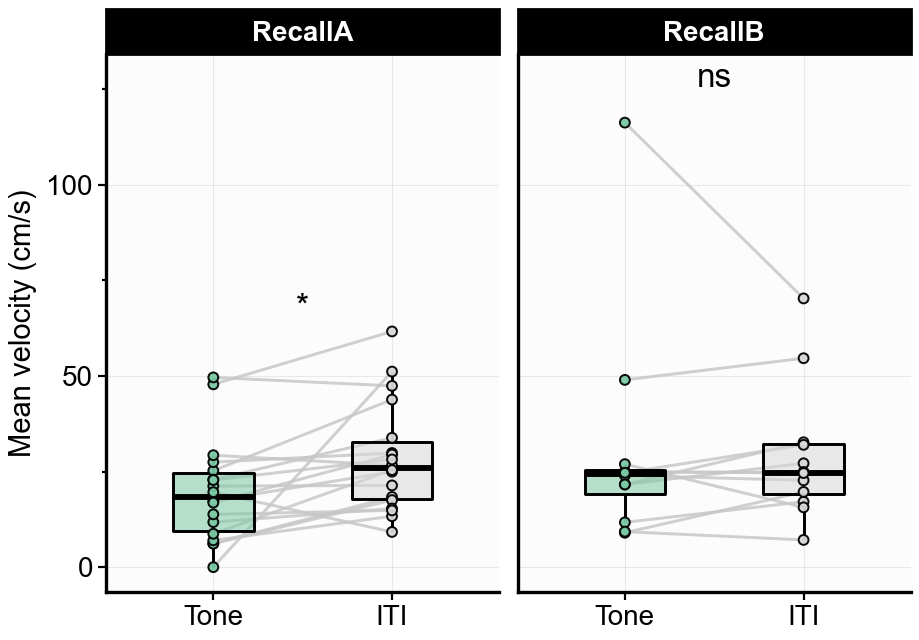

In [151]:
from plotnine import (
    ggplot, aes, geom_boxplot, geom_line, geom_point, geom_text,
    facet_wrap, theme_gray, theme, labs, scale_fill_manual,
    element_text, element_blank, element_line, element_rect
)

def plot_trace_vs_iti_combined_plotnine():
    TRACE_COLOR = "#7BC8A4"
    ITI_COLOR = "#D9D9D9"
    LINE_COLOR = "#C7C7C7"
    EDGE_COLOR = "#000000"
    PANEL_BG = "#FCFCFC"

    stats, rows = [], []

    for sess in ["RecallA", "RecallB"]:
        d = recall_tbl[recall_tbl["session"] == sess].copy()
        if d.empty:
            continue

        y1 = d["Tone"].astype(float).values
        y2 = d["ITI"].astype(float).values
        t_p = ttest_rel(y1, y2).pvalue if len(d) > 1 else np.nan

        stats.append({
            "comparison": "Tone vs ITI", "session": sess, "n": len(d),
            "target_mean": np.nanmean(y1), "ITI_mean": np.nanmean(y2),
            "ratio_mean": np.nanmean(y1 / y2), "paired_t_p": t_p
        })

        for _, row in d.iterrows():
            rows += [
                {"mouse_id": row["mouse_id"], "session": sess,
                 "group": "Tone", "velocity": row["Tone"]},
                {"mouse_id": row["mouse_id"], "session": sess,
                 "group": "ITI", "velocity": row["ITI"]}
            ]

    long_df = pd.DataFrame(rows)
    long_df["session"] = pd.Categorical(
        long_df["session"], ["RecallA", "RecallB"], ordered=True
    )
    long_df["group"] = pd.Categorical(
        long_df["group"], ["Tone", "ITI"], ordered=True
    )

    stats_df = pd.DataFrame(stats)

    label_df = stats_df.merge(
        long_df.groupby("session", observed=True)["velocity"]
        .max().rename("y_max").reset_index(),
        on="session"
    )

    def p_label(p):
        if p < .0001: return "****"
        if p < .001: return "***"
        if p < .01: return "**"
        if p < .05: return "*"
        return "ns"

    label_df["label"] = label_df["paired_t_p"].apply(p_label)
    label_df["x"] = 1.5
    label_df["y"] = label_df["y_max"] * 1.10

    p = (
        ggplot(long_df, aes("group", "velocity"))
        + geom_line(
            aes(group="mouse_id"),
            color=LINE_COLOR, alpha=.85, size=.6
        )
        + geom_boxplot(
            aes(fill="group"),
            width=.45, alpha=.55,
            outlier_shape="", color=EDGE_COLOR, size=.6
        )
        + geom_point(
            aes(fill="group"),
            shape="o", size=1.6,
            stroke=.4, color=EDGE_COLOR, alpha=.95
        )
        + geom_text(
            label_df, aes("x", "y", label="label"),
            inherit_aes=True, size=12, color="black"
        )
        + facet_wrap("~session", nrow=1)
        + scale_fill_manual(values={
            "Tone": TRACE_COLOR,
            "ITI": ITI_COLOR
        })
        + labs(x="", y="Mean velocity (cm/s)")
        + theme_gray(base_family="Arial", base_size=11)
        + theme(
            figure_size=(4.6, 3.2),
            panel_spacing=.02,
            legend_position="none",
            panel_background=element_rect(fill=PANEL_BG, color=None),
            panel_grid_major=element_line(color="black", alpha=.08, size=.4),
            panel_grid_minor=element_blank(),
            strip_background=element_rect(fill="black", color="black"),
            strip_text=element_text(color="white", weight="bold", size=10),
            axis_line_x=element_line(color="black", size=1.2),
            axis_line_y=element_line(color="black", size=1.2),
            axis_ticks=element_line(color="black", size=.8),
            axis_text=element_text(color="black", size=10),
            axis_title_y=element_text(color="black", size=10.5)
        )
    )

    base = OUTPUT_DIR / "RecallA_RecallB_Tone_vs_ITI_allmice_mainplot"
    p.save(base.with_suffix(".png"), dpi=300, verbose=False)
    p.save(base.with_suffix(".svg"), dpi=300, verbose=False)

    stats_df.to_csv(
        OUTPUT_DIR / "RecallA_RecallB_Tone_vs_ITI_stats_allmice.csv",
        index=False
    )

    display(
        stats_df.style.format({
            "target_mean": "{:.2f}",
            "ITI_mean": "{:.2f}",
            "ratio_mean": "{:.2f}",
            "paired_t_p": "{:.4f}"
        })
    )

    return p

plot_trace_vs_iti_combined_plotnine()

Plot the RecallA vs B difference

,comparison,test,n,mean_Tone,mean_ITI,mean_difference,t,p
0,RecallA: Tone vs ITI,paired t-test,18,19.65,28.45,-8.80,-2.882,0.0104
1,RecallB: Tone vs ITI,paired t-test,12,30.31,29.03,1.28,0.289,0.7778
2,RecallA vs RecallB: Tone - ITI,Welch independent t-test,18 vs 12,nan,nan,10.09,-1.871,0.0755


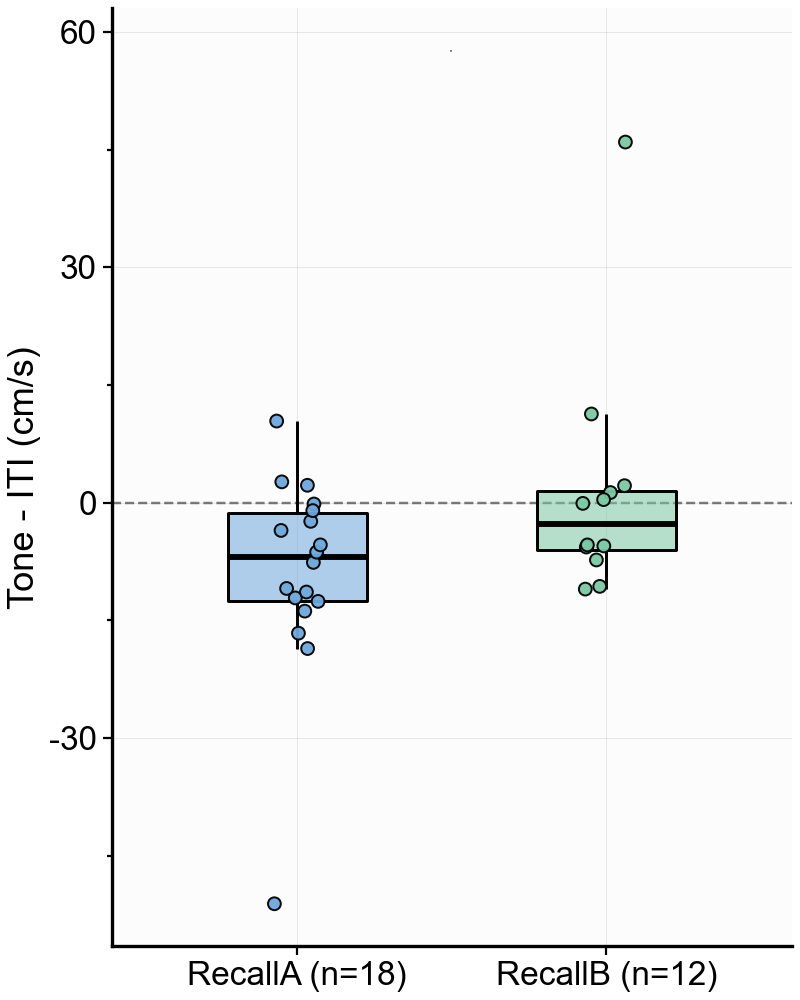

(<plotnine.ggplot.ggplot at 0x181de86d0>,
 epoch  mouse_id  session        Tone        ITI  difference   session_label
 0          671B  RecallA   25.216144  43.813215  -18.597071  RecallA (n=18)
 1          671L  RecallA   17.343239  24.958978   -7.615739  RecallA (n=18)
 2          671N  RecallA   21.194211  21.367719   -0.173508  RecallA (n=18)
 3          672B  RecallA   47.790758  61.617450  -13.826692  RecallA (n=18)
 4          672L  RecallA    6.197000  18.343183  -12.146184  RecallA (n=18)
 5          672N  RecallA    6.143652  17.534374  -11.390722  RecallA (n=18)
 6          672R  RecallA   27.454852  29.838342   -2.383490  RecallA (n=18)
 7           759  RecallA   49.603452  47.393346    2.210105  RecallA (n=18)
 8          760L  RecallA   19.602332   9.206325   10.396006  RecallA (n=18)
 9          760R  RecallA   11.782137  15.326944   -3.544808  RecallA (n=18)
 10          H14  RecallA   29.270163  26.623711    2.646453  RecallA (n=18)
 11          H18  RecallA   16.857

In [152]:
from scipy.stats import ttest_rel, ttest_ind
from plotnine import (
    ggplot, aes, geom_boxplot, geom_jitter, geom_hline, geom_text,
    theme_gray, theme, labs, scale_fill_manual,
    element_text, element_blank, element_line, element_rect
)

def plot_tonetrace_minus_iti_across_recall(recall_tbl, name="RecallA_vs_RecallB_Tone_minus_ITI_allmice"):
    d = recall_tbl.loc[
        recall_tbl["session"].isin(["RecallA", "RecallB"]),
        ["mouse_id", "session", "Tone", "ITI"]
    ].dropna().copy()

    d["difference"] = d["Tone"] - d["ITI"]

    # Within-session paired tests
    stats_rows = []
    for sess in ["RecallA", "RecallB"]:
        s = d[d["session"] == sess].copy()
        t, p = ttest_rel(s["Tone"], s["ITI"]) if len(s) > 1 else (np.nan, np.nan)
        stats_rows.append({
            "comparison": f"{sess}: Tone vs ITI",
            "test": "paired t-test",
            "n": len(s),
            "mean_Tone": s["Tone"].mean(),
            "mean_ITI": s["ITI"].mean(),
            "mean_difference": s["difference"].mean(),
            "t": t,
            "p": p
        })

    # Between-session test on difference score
    a = d.loc[d["session"] == "RecallA", "difference"]
    b = d.loc[d["session"] == "RecallB", "difference"]
    t_between, p_between = ttest_ind(a, b, equal_var=False)

    stats_rows.append({
        "comparison": "RecallA vs RecallB: Tone - ITI",
        "test": "Welch independent t-test",
        "n": f"{len(a)} vs {len(b)}",
        "mean_Tone": np.nan,
        "mean_ITI": np.nan,
        "mean_difference": b.mean() - a.mean(),
        "t": t_between,
        "p": p_between
    })

    stats_df = pd.DataFrame(stats_rows)

    d["session"] = pd.Categorical(d["session"], ["RecallA", "RecallB"], ordered=True)

    n_df = d.groupby("session", observed=True)["mouse_id"].nunique().to_dict()
    d["session_label"] = d["session"].map(lambda s: f"{s} (n={n_df[s]})")
    label_order = [f"{s} (n={n_df[s]})" for s in ["RecallA", "RecallB"] if s in n_df]
    d["session_label"] = pd.Categorical(d["session_label"], label_order, ordered=True)

    def p_label(p):
        if p < .0001: return "****"
        if p < .001: return "***"
        if p < .01: return "**"
        if p < .05: return "*"
        return "ns"

    y_max = d["difference"].max()
    y_min = d["difference"].min()
    y_range = y_max - y_min if y_max > y_min else 1
    label_df = pd.DataFrame([{
        "x": 1.5,
        "y": y_max + y_range * 0.12,
        "label": p_label(p_between)
    }])

    SESSION_COLORS = {"RecallA": "#6FA8DC", "RecallB": "#7BC8A4"}

    p = (
        ggplot(d, aes("session_label", "difference"))
        + geom_hline(yintercept=0, linetype="dashed", color="black", alpha=.5, size=.5)
        + geom_boxplot(
            aes(fill="session"),
            width=.45, alpha=.55,
            outlier_shape="", color="black", size=.6
        )
        + geom_jitter(
            aes(fill="session"),
            width=.08, height=0,
            shape="o", size=2.2, stroke=.4,
            color="black", alpha=.95
        )
        + geom_text(
            label_df, aes("x", "y", label="label"),
            inherit_aes=False, size=1, color="black"
        )
        + scale_fill_manual(values=SESSION_COLORS)
        + labs(
            x="",
            y="Tone - ITI (cm/s)"
        )
        + theme_gray(base_family="Arial", base_size=13)
            + theme(
                figure_size=(4, 5),
                legend_position="none",

                panel_background=element_rect(fill="#FCFCFC", color=None),
                panel_grid_major=element_line(color="black", alpha=.08, size=.4),
                panel_grid_minor=element_blank(),

                axis_line_x=element_line(color="black", size=1.2),
                axis_line_y=element_line(color="black", size=1.2),
                axis_ticks=element_line(color="black", size=.8),

                axis_text_x=element_text(color="black", size=12),
                axis_text_y=element_text(color="black", size=12),
                axis_title_y=element_text(color="black", size=13),

                strip_background=element_rect(fill="black", color="black"),
                strip_text=element_text(color="white", weight="bold", size=13)
)
    )

    p.save(OUTPUT_DIR / f"{name}.png", dpi=300, verbose=False)
    p.save(OUTPUT_DIR / f"{name}.svg", dpi=300, verbose=False)
    stats_df.to_csv(OUTPUT_DIR / f"{name}_stats.csv", index=False)
    d.to_csv(OUTPUT_DIR / f"{name}_values.csv", index=False)

    display(
        stats_df.style.format({
            "mean_Tone": "{:.2f}",
            "mean_ITI": "{:.2f}",
            "mean_difference": "{:.2f}",
            "t": "{:.3f}",
            "p": "{:.4f}"
        })
    )
    display(p)
    return p, d, stats_df

plot_tonetrace_minus_iti_across_recall(recall_tbl)